# 📑 Tutorials for PyPOTS Imputation Models
## 📀 Preparing the  **Electricity** dataset for this tutorial

In [2]:
from benchpots.datasets import preprocess_electricity_load_diagrams

# Load the dataset with artificially missing values
electricity = preprocess_electricity_load_diagrams(subset="all", rate=0.1, n_steps=100)

2025-03-06 17:42:55 [INFO]: You're using dataset electricity_load_diagrams, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/electricity_load_diagrams
2025-03-06 17:42:55 [INFO]: Dataset electricity_load_diagrams has already been downloaded. Processing directly...
2025-03-06 17:42:55 [INFO]: Dataset electricity_load_diagrams has already been cached. Loading from cache directly...
2025-03-06 17:42:56 [INFO]: Loaded successfully!
2025-03-06 17:42:56 [INFO]: months selected as test set are <PeriodArray>
['2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07',
 '2011-08', '2011-09', '2011-10']
Length: 10, dtype: period[M]
2025-03-06 17:42:56 [INFO]: months selected as val set are <PeriodArray>
['2011-11', '2011-12', '2012-01', '2012-02', '2012-03', '2012-04', '2012-05',
 '2012-06', '2012-07', '2012-08']
Length: 10, dtype: period[M]
2025-03-06 17:42:56 [INFO]: mon

In [3]:
electricity.keys()

dict_keys(['n_steps', 'n_features', 'scaler', 'train_X', 'val_X', 'test_X', 'train_X_ori', 'val_X_ori', 'test_X_ori'])

In [4]:
# Assemble the datasets for training, validating, and testing.

dataset_for_training = {
    "X": electricity['train_X'],
}

dataset_for_validating = {
    "X": electricity['val_X'],
    "X_ori": electricity['val_X_ori'],
}

dataset_for_testing = {
    "X": electricity['test_X'],
    "X_ori": electricity['test_X_ori']
}


## División en entrenamiento, validación y testing

Electricity Load Diagrams (Electricity) This is another widely-used public dataset from UCI [50]. It contains
electricity consumption data (in kWh) collected from 370 clients every 15 minutes and has no missing data. The period
of this dataset is from 2011/01/01 to 2014/12/31 (48 months in total). Similar to processing Air-Quality, we use the
first 10 months of data (2011/01 - 2011/10) as the test set, the following 10 months of data (2011/11 - 2012/08) as
the validation set and the left (2012/09 - 2014/12) as the training set. Every 100 consecutive steps are selected as a
sample to generate time-series data for model training. Due to this dataset having no missing values, we vary artificial
missing rate from 10% ∼ 90% to eliminate observed values in the training set, validation set, and test set. This can
make the comparison between our method and other SOTA models more comprehensive. Artificial missing values in
the validation and test set are held out for model evaluation. Experiment results of 10% missing values are displayed in
Table 2. Results of 20% ∼ 90% missing values are shown in Table 4.

In [5]:
dataset_for_testing['X_ori']

array([[[-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        ...,
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125]],

       [[-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        ...,
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.

In [11]:
dataset_for_testing['X']

array([[[-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [       nan, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        ...,
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 , -2.3388805, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 , -2.3388805, ...,        nan,
         -5.9057603, -2.0794125]],

       [[-0.7906768, -4.355275 , -2.3388805, ...,        nan,
         -5.9057603, -2.0794125],
        [-0.7906768,        nan,        nan, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.7906768, -4.355275 ,        nan, ..., -1.8287051,
                nan, -2.0794125],
        ...,
        [-0.7906768, -4.355275 ,        nan, ..., -1.8287051,
         -5.9057603, -2.0794125],
        [-0.

In [9]:
features = {
    f"MT_{str(i).zfill(3)}": None for i in range(1, 371)
}
len(features)

370

In [25]:
import pandas as pd
import numpy as np

# Supongamos que 'dataset_for_testing['X']' es tu numpy array de shape (817, 100, 370)
# Reestructuramos el array para convertirlo en un formato adecuado para series temporales multivariantes
# Transponemos y aplanamos para que tengamos (291 * 100, 1370)

X_reshaped = dataset_for_testing['X'].reshape(-1, 370)

# Ahora X_reshaped tiene la forma (291 * 100, 132)

# Creamos un índice para las filas basado en el paso temporal
index = pd.MultiIndex.from_product([range(291), range(100)], names=['Sample', 'Time'])

# Creamos el DataFrame
df = pd.DataFrame(X_reshaped, columns=features, index=index)

# Mostrar las primeras filas del DataFrame
df

MT_001    MT_002    MT_003    MT_004    MT_005    MT_006  \
Sample Time                                                               
0      0    -0.790677 -4.355275 -2.338881 -2.881208 -2.841798       NaN   
       1          NaN -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       2    -0.790677 -4.355275 -2.338881       NaN -2.841798 -2.943682   
       3    -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       4    -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
...               ...       ...       ...       ...       ...       ...   
290    95   -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       96   -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       97   -0.790677       NaN -2.338881 -2.881208 -2.841798 -2.943682   
       98   -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       99   -0.790677 -4.355275 -2.338881       NaN -2.841798 -2.943682   

               MT_007   MT_008   MT_009    MT_010  ...   MT_361    MT_362  \
Sample Time                                        ...                      
0      0    -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       1          NaN -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       2    -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       3    -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064       NaN   
       4    -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
...               ...      ...      ...       ...  ...      ...       ...   
290    95   -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064       NaN   
       96         NaN -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       97   -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       98   -0.899485 -4.34013 -2.48492       NaN  ... -1.57064 -1.370245   
       99   -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064       NaN   

               MT_363    MT_364    MT_365    MT_366    MT_367    MT_368  \
Sample Time                                                               
0      0    -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       1    -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       2    -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       3    -1.512596 -1.542578 -1.452005 -1.266252       NaN -1.828705   
       4    -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
...               ...       ...       ...       ...       ...       ...   
290    95   -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       96   -1.512596 -1.542578       NaN -1.266252 -3.755072 -1.828705   
       97   -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       98   -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       99   -1.512596       NaN -1.452005 -1.266252 -3.755072 -1.828705   

              MT_369    MT_370  
Sample Time                     
0      0    -5.90576 -2.079412  
       1    -5.90576 -2.079412  
       2    -5.90576 -2.079412  
       3    -5.90576 -2.079412  
       4         NaN -2.079412  
...              ...       ...  
290    95   -5.90576 -2.079412  
       96   -5.90576       NaN  
       97        NaN -2.079412  
       98   -5.90576 -2.079412  
       99   -5.90576 -2.079412  

[29100 rows x 370 columns]

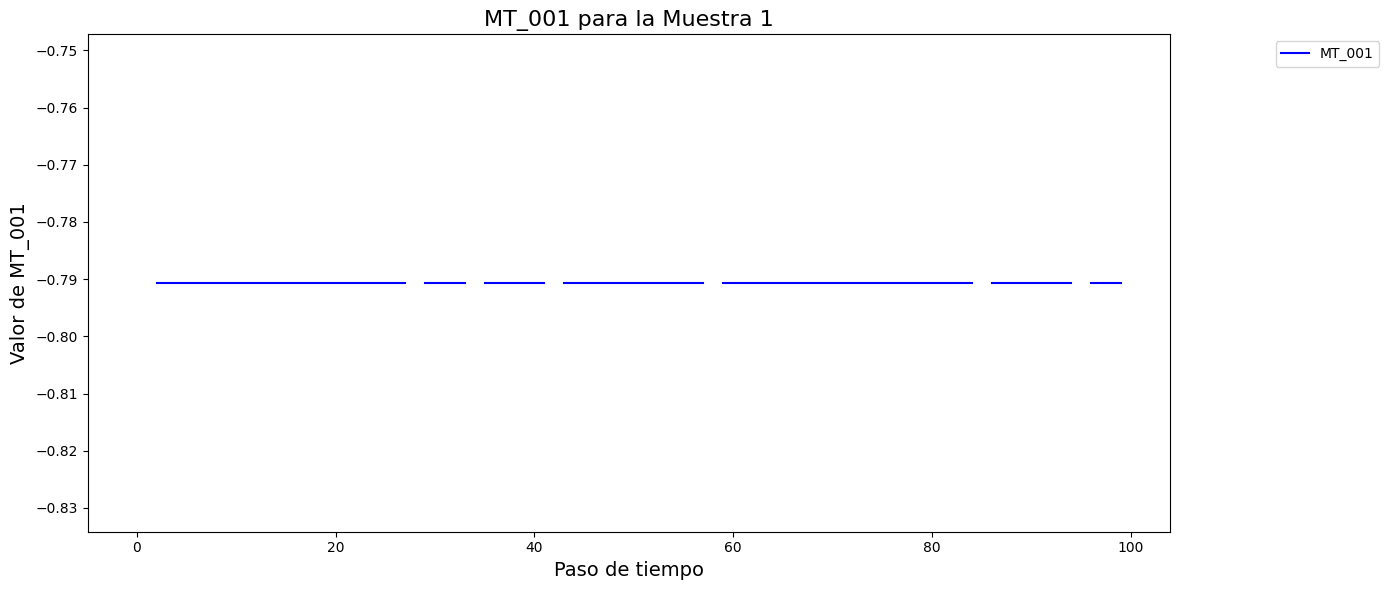

In [26]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(100)  # 100 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df.loc[sample_index, ['MT_001', 'MT_002']]

# Crear gráfico para Feature 1
plt.figure(figsize=(14, 6))
if sample_data['MT_001'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['MT_001'], label='MT_001', color='b')
    plt.title(f'MT_001 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de MT_001', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para MT_001 en la muestra.")



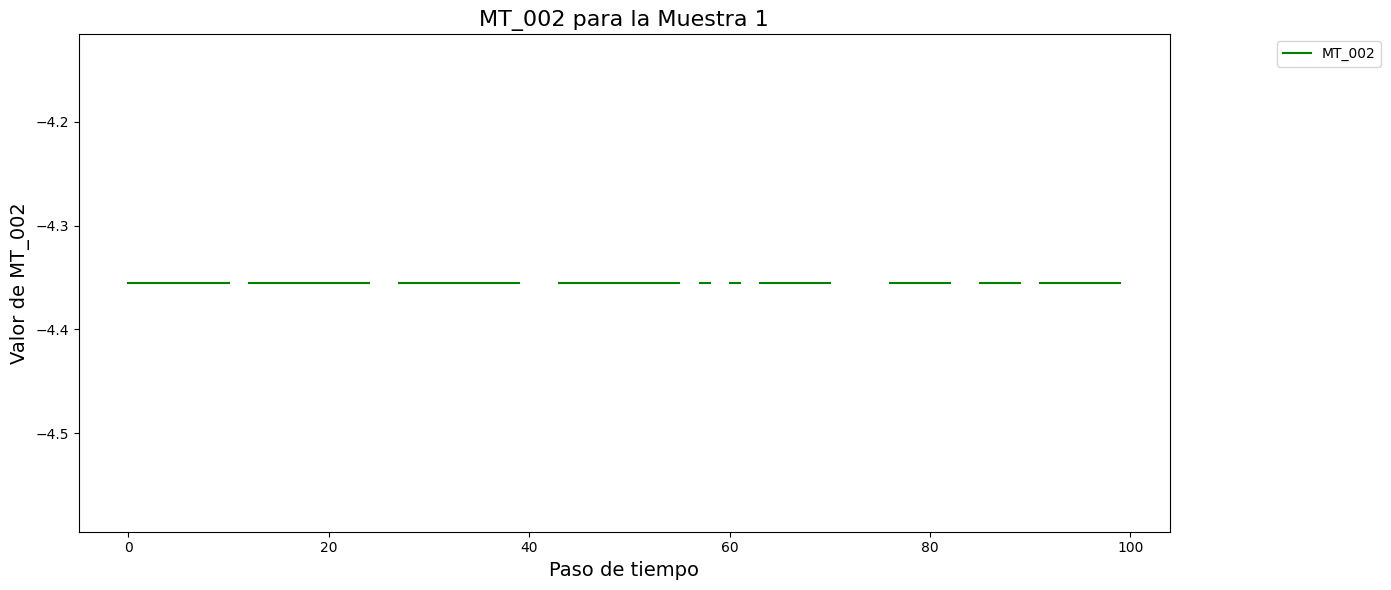

In [27]:
# Crear gráfico para MT_002
plt.figure(figsize=(14, 6))
if sample_data['MT_002'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['MT_002'], label='MT_002', color='g')
    plt.title(f'MT_002 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de MT_002', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para MT_002 en la muestra.")

# Mostrar los gráficos
plt.show()


In [28]:
electricity['n_steps']

100

In [29]:
electricity['n_features']

370

## 🚀 An example of **SAITS** for imputation

In [30]:
from pypots.optim import Adam
from pypots.imputation import SAITS

# initialize the model
saits = SAITS(
    n_steps=electricity['n_steps'],
    n_features=electricity['n_features'],
    n_layers=2,
    d_model=256,
    d_ffn=128,
    n_heads=4,
    d_k=64,
    d_v=64,
    dropout=0.1,
    attn_dropout=0.1,
    ##### Esto diferencia al SAIT del modelo Transformer
    diagonal_attention_mask=True,  # otherwise the original self-attention mechanism will be applied
    ORT_weight=1,  # you can adjust the weight values of arguments ORT_weight
    # and MIT_weight to make the SAITS model focus more on one task. Usually you can just leave them to the default values, i.e. 1.
    MIT_weight=1,
    batch_size=32,
    # here we set epochs=10 for a quick demo, you can set it to 100 or more for better performance
    epochs=10,
    # here we set patience=3 to early stop the training if the evaluting loss doesn't decrease for 3 epoches.
    # You can leave it to defualt as None to disable early stopping.
    patience=3,
    # give the optimizer. Different from torch.optim.Optimizer, you don't have to specify model's parameters when
    # initializing pypots.optim.Optimizer. You can also leave it to default. It will initilize an Adam optimizer with lr=0.001.
    optimizer=Adam(lr=1e-3),
    # this num_workers argument is for torch.utils.data.Dataloader. It's the number of subprocesses to use for data loading.
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    # You can increase it to >1 if you think your dataloading is a bottleneck to your model training speed
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    # Set it as 'cpu' if you don't have CUDA devices. You can also set it to 'cuda:0' or 'cuda:1' if you have multiple CUDA devices, even parallelly on ['cuda:0', 'cuda:1']
    device=None,  
    # set the path for saving tensorboard and trained model files 
    saving_path="tutorial_results/imputation/saits",
    # only save the best model after training finished.
    # You can also set it as "better" to save models performing better ever during training.
    model_saving_strategy="best",
)


/Users/eigenric/.local/share/virtualenvs/TFG--n4J6ECg/lib/python3.13/site-packages/pypots/nn/modules/reformer/local_attention.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/Users/eigenric/.local/share/virtualenvs/TFG--n4J6ECg/lib/python3.13/site-packages/pypots/nn/modules/reformer/local_attention.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
2025-03-06 17:57:57 [INFO]: No given device, using default device: cpu
2025-03-06 17:57:57 [INFO]: Model files will be saved to tutorial_results/imputation/saits/20250306_T175757
2025-03-06 17:57:57 [INFO]: Tensorboard file will be saved to tutorial_results/imputation/saits/20250306_T175757/tensorboard
2025-03-06 17:57:57 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 2,197,464



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



In [31]:
# train the model on the training set, and validate it on the validating set to select the best model for testing in the next step
saits.fit(train_set=dataset_for_training, val_set=dataset_for_validating)


2025-03-06 17:58:11 [INFO]: Epoch 001 - training loss: 1.0253, validation loss: 3.1050
2025-03-06 17:58:22 [INFO]: Epoch 002 - training loss: 0.7098, validation loss: 2.9637
2025-03-06 17:58:33 [INFO]: Epoch 003 - training loss: 0.6412, validation loss: 2.8662
2025-03-06 17:58:44 [INFO]: Epoch 004 - training loss: 0.6110, validation loss: 2.7971
2025-03-06 17:58:55 [INFO]: Epoch 005 - training loss: 0.5895, validation loss: 2.7877
2025-03-06 17:59:05 [INFO]: Epoch 006 - training loss: 0.5732, validation loss: 2.7786
2025-03-06 17:59:16 [INFO]: Epoch 007 - training loss: 0.5600, validation loss: 2.7728
2025-03-06 17:59:27 [INFO]: Epoch 008 - training loss: 0.5476, validation loss: 2.7783
2025-03-06 17:59:38 [INFO]: Epoch 009 - training loss: 0.5382, validation loss: 2.7546
2025-03-06 17:59:51 [INFO]: Epoch 010 - training loss: 0.5303, validation loss: 2.7474
2025-03-06 17:59:51 [INFO]: Finished training. The best model is from epoch#10.
2025-03-06 17:59:51 [INFO]: Saved the model to tut

In [32]:
# the testing stage, impute the originally-missing values and artificially-missing values in the test set

saits_results = saits.predict(dataset_for_testing)
saits_imputation = saits_results["imputation"]


In [33]:
saits_imputation

array([[[-0.7906768 , -4.355275  , -2.3388805 , ..., -1.8287051 ,
         -5.9057603 , -2.0794125 ],
        [ 0.01223738, -4.355275  , -2.3388805 , ..., -1.8287051 ,
         -5.9057603 , -2.0794125 ],
        [-0.7906768 , -4.355275  , -2.3388805 , ..., -1.8287051 ,
         -5.9057603 , -2.0794125 ],
        ...,
        [-0.7906768 , -4.355275  , -2.3388805 , ..., -1.8287051 ,
         -5.9057603 , -2.0794125 ],
        [-0.7906768 , -4.355275  , -2.3388805 , ..., -1.8287051 ,
         -5.9057603 , -2.0794125 ],
        [-0.7906768 , -4.355275  , -2.3388805 , ..., -1.1069839 ,
         -5.9057603 , -2.0794125 ]],

       [[-0.7906768 , -4.355275  , -2.3388805 , ..., -1.2743804 ,
         -5.9057603 , -2.0794125 ],
        [-0.7906768 , -0.89728725, -0.60024536, ..., -1.8287051 ,
         -5.9057603 , -2.0794125 ],
        [-0.7906768 , -4.355275  , -0.5907013 , ..., -1.8287051 ,
         -2.1414883 , -2.0794125 ],
        ...,
        [-0.7906768 , -4.355275  , -0.59643364, ..., -

In [34]:
import pandas as pd
import numpy as np

# Supongamos que 'dataset_for_testing['X']' es tu numpy array de shape (291,100, 370)
# Reestructuramos el array para convertirlo en un formato adecuado para series temporales multivariantes
# Transponemos y aplanamos para que tengamos (291 * 100, 370)

X_reshaped = saits_imputation.reshape(-1, 370)

# Ahora X_reshaped tiene la forma (291 * 100, 370)

# Creamos un índice para las filas basado en el paso temporal
index = pd.MultiIndex.from_product([range(291), range(100)], names=['Sample', 'Time'])

# Creamos el DataFrame
df_imputation = pd.DataFrame(X_reshaped, columns=features, index=index)

# Mostrar las primeras filas del DataFrame
df_imputation

MT_001    MT_002    MT_003    MT_004    MT_005    MT_006  \
Sample Time                                                               
0      0    -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -1.704971   
       1     0.012237 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       2    -0.790677 -4.355275 -2.338881 -1.128380 -2.841798 -2.943682   
       3    -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       4    -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
...               ...       ...       ...       ...       ...       ...   
290    95   -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       96   -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       97   -0.790677 -0.698587 -2.338881 -2.881208 -2.841798 -2.943682   
       98   -0.790677 -4.355275 -2.338881 -2.881208 -2.841798 -2.943682   
       99   -0.790677 -4.355275 -2.338881 -1.264340 -2.841798 -2.943682   

               MT_007   MT_008   MT_009    MT_010  ...   MT_361    MT_362  \
Sample Time                                        ...                      
0      0    -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       1    -0.932541 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       2    -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       3    -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -0.634689   
       4    -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
...               ...      ...      ...       ...  ...      ...       ...   
290    95   -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -0.689322   
       96   -1.001432 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       97   -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -1.370245   
       98   -0.899485 -4.34013 -2.48492 -0.897002  ... -1.57064 -1.370245   
       99   -0.899485 -4.34013 -2.48492 -2.206397  ... -1.57064 -0.698322   

               MT_363    MT_364    MT_365    MT_366    MT_367    MT_368  \
Sample Time                                                               
0      0    -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       1    -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       2    -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       3    -1.512596 -1.542578 -1.452005 -1.266252 -1.436626 -1.828705   
       4    -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
...               ...       ...       ...       ...       ...       ...   
290    95   -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       96   -1.512596 -1.542578 -0.990207 -1.266252 -3.755072 -1.828705   
       97   -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       98   -1.512596 -1.542578 -1.452005 -1.266252 -3.755072 -1.828705   
       99   -1.512596 -0.699472 -1.452005 -1.266252 -3.755072 -1.828705   

               MT_369    MT_370  
Sample Time                      
0      0    -5.905760 -2.079412  
       1    -5.905760 -2.079412  
       2    -5.905760 -2.079412  
       3    -5.905760 -2.079412  
       4    -2.186617 -2.079412  
...               ...       ...  
290    95   -5.905760 -2.079412  
       96   -5.905760 -0.446465  
       97   -2.110030 -2.079412  
       98   -5.905760 -2.079412  
       99   -5.905760 -2.079412  

[29100 rows x 370 columns]

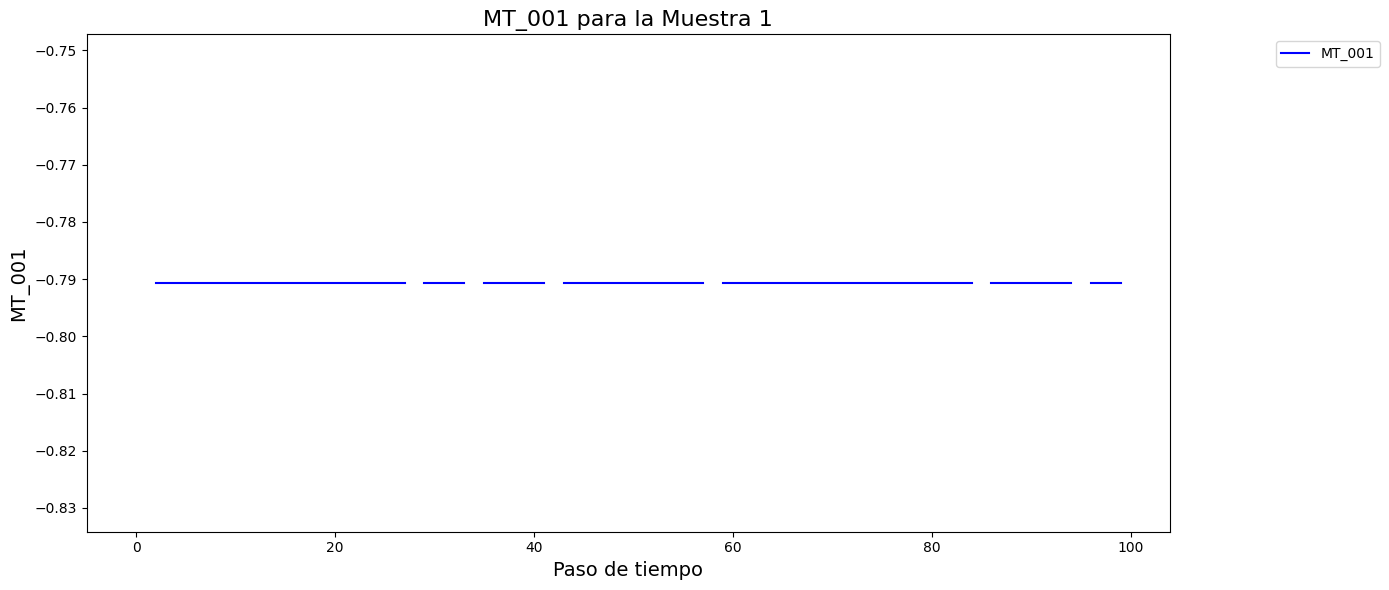

In [36]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(100)  # 100 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df.loc[sample_index, ['MT_001', 'MT_002']]

# Crear gráfico para MT_001
plt.figure(figsize=(14, 6))
if sample_data['MT_001'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['MT_001'], label='MT_001', color='b')
    plt.title(f'MT_001 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('MT_001', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Feature 0 en la muestra.")



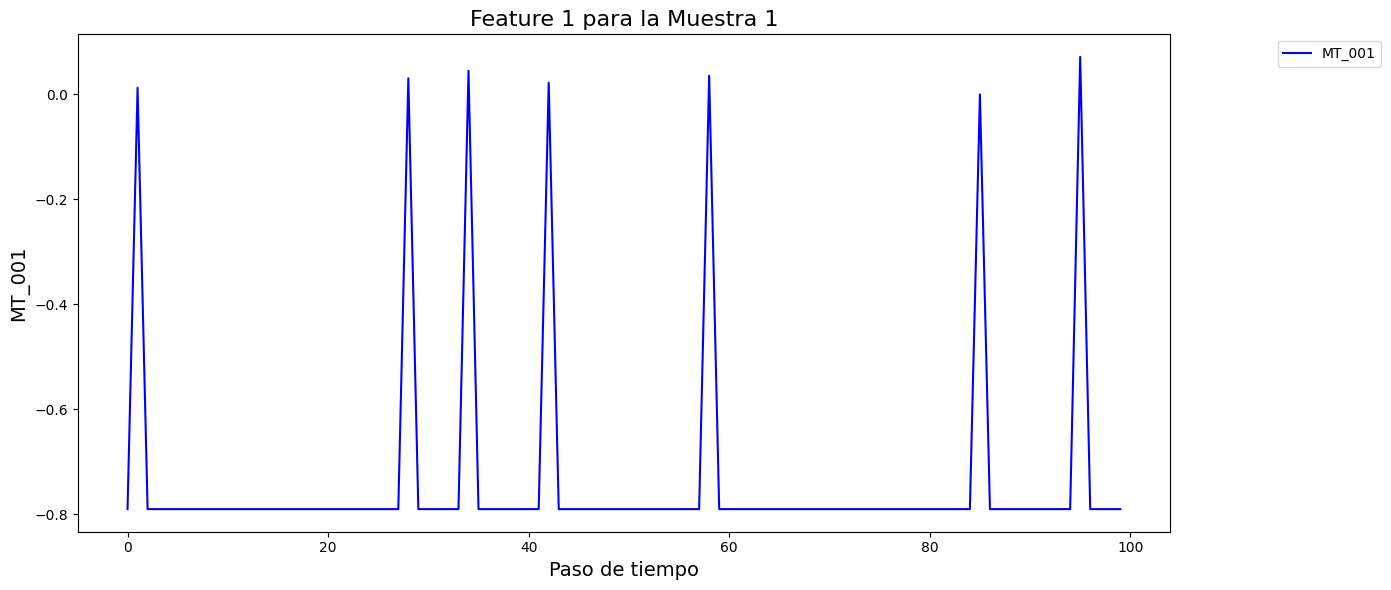

In [39]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(100)  # 100 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df_imputation.loc[sample_index, ['MT_001', 'MT_002']]

# Crear gráfico para Ritmo Cardíaco (HR)
plt.figure(figsize=(14, 6))
if sample_data['MT_001'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['MT_001'], label='MT_001', color='b')
    plt.title(f'Feature 1 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('MT_001', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para Feature 0 en la muestra.")



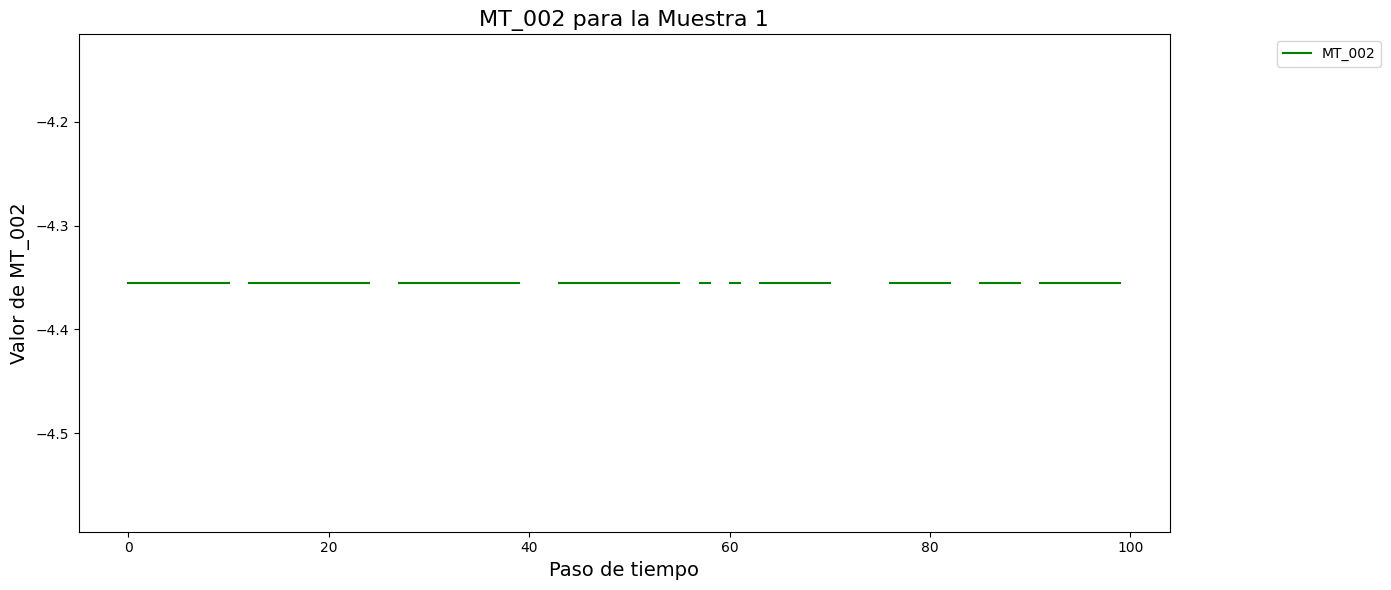

In [40]:
sample_data = df.loc[sample_index, ['MT_001', 'MT_002']]

# Crear gráfico para Feature 0
plt.figure(figsize=(14, 6))
if sample_data['MT_002'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['MT_002'], label='MT_002', color='g')
    plt.title(f'MT_002 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de MT_002', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para MT_002 en la muestra.")

# Mostrar los gráficos
plt.show()



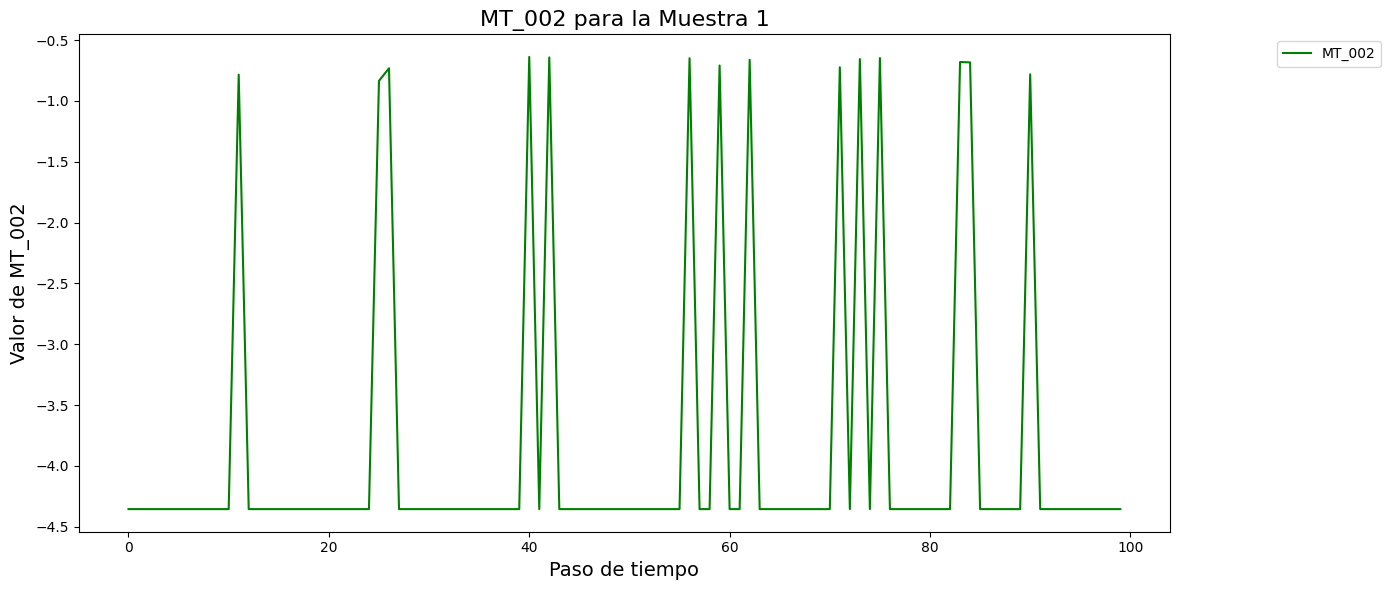

In [42]:
sample_data = df_imputation.loc[sample_index, ['MT_001', 'MT_002']]

# Crear gráfico para Presión Arterial No Invasiva (NIMAP)
plt.figure(figsize=(14, 6))
if sample_data['MT_002'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['MT_002'], label='MT_002', color='g')
    plt.title(f'MT_002 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de MT_002', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para MT_002 en la muestra.")

# Mostrar los gráficos
plt.show()

In [43]:
saits_imputation.shape

(291, 100, 370)

In [47]:
from pypots.utils.metrics import calc_mae

electricity['test_X_indicating_mask'] = np.isnan(electricity['test_X']).astype(int)

# Crear una copia de los datos originales
test_X_ori_fixed = np.copy(electricity['test_X_ori'])

# Reemplazar NaNs por 0 (valor constante)
test_X_ori_fixed[np.isnan(test_X_ori_fixed)] = 0

# Verificar si quedan NaNs
num_nans_fixed = np.isnan(test_X_ori_fixed).sum()
print(f"Número de NaNs en test_X_ori después de imputación (con 0): {num_nans_fixed}")

# calculate mean absolute error on the ground truth (artificially-missing values)
# predictions, targets, masks
testing_mae = calc_mae(
    saits_imputation, 
    test_X_ori_fixed, 
    electricity['test_X_indicating_mask'],
)
print(f"Testing mean absolute error (MAE): {testing_mae:.4f}")

Número de NaNs en test_X_ori después de imputación (con 0): 0
Testing mean absolute error (MAE): 1.2987
